# Code for reproducing Figure S2 plots for the D16 data
## This notebooks depend on first generating the processed and clustered data

last updated: 2024116

## Import data and functions

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set a path to your working directory
directory='/Set/your/path/'

# load .h5ad with processed data 
adata = sc.read_h5ad(directory+'/Written_files/D16_GEX_processed-clustered.h5ad')

print(adata)

AnnData object with n_obs × n_vars = 73077 × 40500
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'experiment', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden'
    var: 'gene_ids-D16_CH2_Chimp', 'feature_types-D16_CH2_Chimp', 'genome-D16_CH2_Chimp', 'gene_ids-D16_CH2_Human', 'feature_types-D16_CH2_Human', 'genome-D16_CH2_Human', 'gene_ids-D16_CH_Chimp', 'feature_types-D16_CH_Chimp', 'genome-D16_CH_Chimp', 'gene_ids-D16_CH_Human', 'feature_types-D16_CH_Human', 'genome-D16_CH_Human', 'gene_ids-D16_M0_5_Chimp', 'feature_types-D16_M0_5_Chimp', 'genome-D16_M0_5_Chimp', 'gene_ids-D16_M0_5_Human', 'feature_types-D16_M0_5_Human', 'genome-D16_M0_5_Human', 'gene_ids-D16_M0_5_Orangutan', 'feature_types-D16_M0_5_Orangutan', 'genome-D16_M0_5_Orangutan', 'gene_ids-D16_M0_5_Rhesus', 'feature_types-D16_M0_5_Rhesus', 'genome-D16_M0_5_Rhesus', 'gene_ids-D16_M2_Chimp', 'feature_types-D16_M2

# Figure panel S2A

UMAPs of D16 cells colored by experiment 


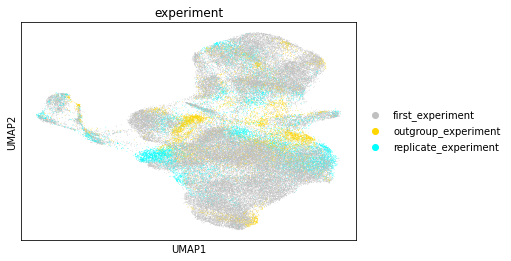

In [3]:
sc.pl.umap(adata, color=['experiment'],save='_D16_experiment.png',
          palette={
        "first_experiment": "silver",
        "replicate_experiment":'cyan',
        "outgroup_experiment": "gold",
        })

# Figure panel S2B

UMAPs of D16 cells colored by pool type 

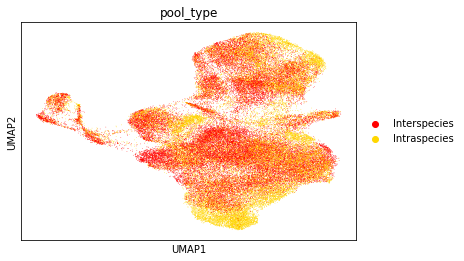

In [4]:
sc.pl.umap(adata, color=['pool_type'],save='_D16_pooltype.png',
           palette={
        "Interspecies": "red",
        "Intraspecies": "gold",
    })

# Figure panel S2C

UMAPs of D16 cells colored by species

In [5]:
#Setting colors for species
adata.uns['species_colors'] = ['blue','orange', 'purple','saddlebrown']
species_colors = adata.uns['species_colors'] 

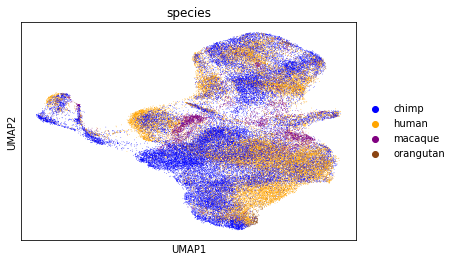

In [6]:
sc.pl.umap(adata, color=['species'], save='_D16_species.png')

# Figure panel S2D

Bar chart showing the number of cells per species for each leiden cluster.

Text(0, 0.5, 'cell number')

<Figure size 432x288 with 0 Axes>

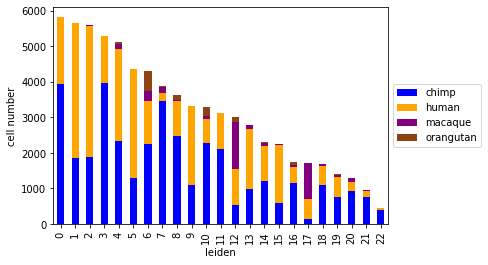

In [7]:
f = plt.figure()
df_plot = adata.obs.groupby(['leiden', 'species']).size().reset_index().pivot(columns='species', index='leiden', values=0)
ax = df_plot.plot(kind='bar',  color=species_colors, legend=False,stacked=True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('cell number')

# Figure panel S2E (D16)

Proportions of individuals in chimpanzee intraspecies pools

In [8]:
# Create obs species_individual
species_individual = pd.Categorical(adata.obs['species'].astype(str) + ('_') + adata.obs['individual'].astype(str))
adata.obs['species_individual'] = species_individual

# only plot cells with assigned identity
adata_D16_proportion = adata[~adata.obs['species_individual'].isin(['chimp_nan','human_nan', 'macaque_nan'])]

# Create subsets of data to plot in Figure S2E-G
adata_intraspecies = adata_D16_proportion[adata_D16_proportion.obs['pool_type'].isin(['Intraspecies'])]
adata_interspecies = adata_D16_proportion[adata_D16_proportion.obs['pool_type'].isin(['Interspecies'])]
adata_intra_chimp = adata_intraspecies[adata_intraspecies.obs['species'].isin(['chimp'])]
adata_intra_human = adata_intraspecies[adata_intraspecies.obs['species'].isin(['human'])]

# Set color scheme
custom_colors = {
    'chimp_C3624': 'cornflowerblue',
    'chimp_C3651': 'royalblue',
    'chimp_C4933': 'navy',
    'chimp_C8861': 'blue',
    'chimp_C40210': 'mediumblue',
    'chimp_C40300': 'dodgerblue',
    'chimp_C40670': 'lightsteelblue',
    'human_H9': 'orange',
    'human_H20961': 'darkkhaki',
    'human_H21194': 'goldenrod',
    'human_H21792': 'navajowhite',
    'human_H23555': 'darkorange',
    'human_H28126': 'khaki',
    'human_H28834': 'yellow',
    'human_H29089': 'gold',
    'macaque_ZG15-M11-10': 'purple',
    'macaque_ES_Lyon': 'mediumvioletred',
    'macaque_ZH26-HS16': 'magenta',
    'orangutan_O11045-4593': 'sienna',
}

<Figure size 432x288 with 0 Axes>

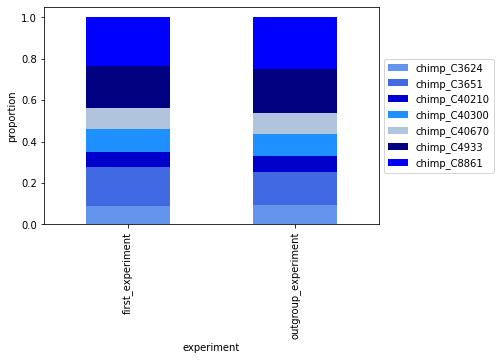

In [9]:

f = plt.figure()
df_plot = adata_intra_chimp.obs.groupby(['species_individual', 'experiment']).size().reset_index().pivot(columns='species_individual', index='experiment', values=0).apply(lambda g: g / g.sum(), 1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

plt.show()


# Figure panel S2F (D16)

Proportions of individuals in human intraspecies pools

<Figure size 432x288 with 0 Axes>

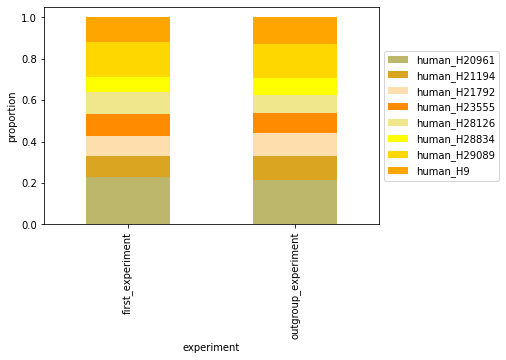

In [10]:
f = plt.figure()
df_plot = adata_intra_human.obs.groupby(['species_individual', 'experiment']).size().reset_index().pivot(columns='species_individual', index='experiment', values=0).apply(lambda g: g / g.sum(), 1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

plt.show()


# Figure panel S2G (D16)

Proportions of individuals in interspecies pools

<Figure size 432x288 with 0 Axes>

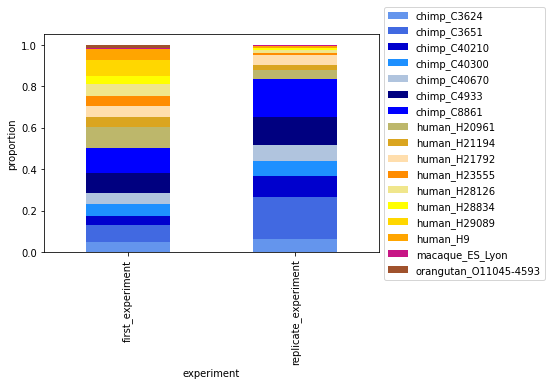

In [11]:

f = plt.figure()
df_plot = adata_interspecies.obs.groupby(['species_individual', 'experiment']).size().reset_index().pivot(columns='species_individual', index='experiment', values=0).apply(lambda g: g / g.sum(), 1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

plt.show()

# Figure panel S2H 

Principal component analysis (PCA) plot of D16 cells showing separation based on species identity along PC1

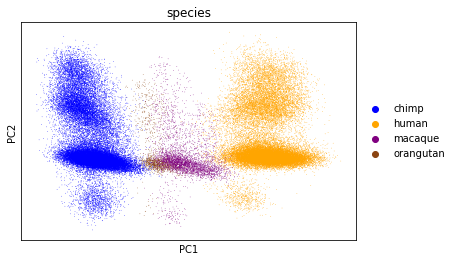

In [12]:
sc.pl.pca(adata, use_raw=False, color='species', save='_D16_species.png')

# Figure panel S2I

PCA plots of D16 cells with projection of SOX2, MKI67 and GAP43 expression levels to illustrate maturation and cell cycle state as major drivers of the separation along PC2.

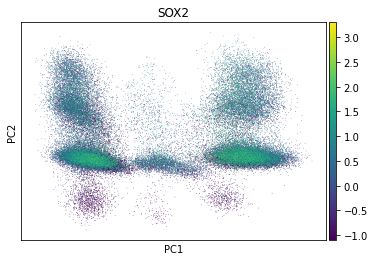

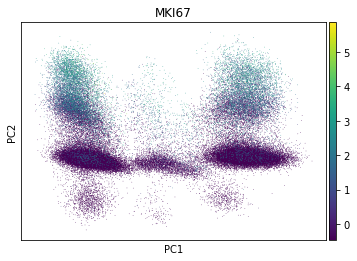

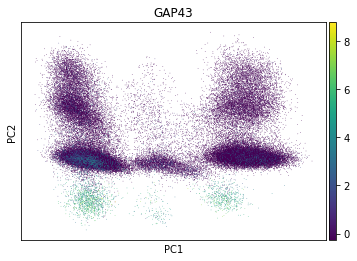

In [13]:
sc.pl.pca(adata, use_raw=False, color='SOX2', save='_D16_SOX2.png')
sc.pl.pca(adata, use_raw=False, color='MKI67', save='_D16_MKI67.png')
sc.pl.pca(adata, use_raw=False, color='GAP43', save='_D16_GAP43.png')

# Figure panel S2J

UMAPs of D16 cells colored by leiden group

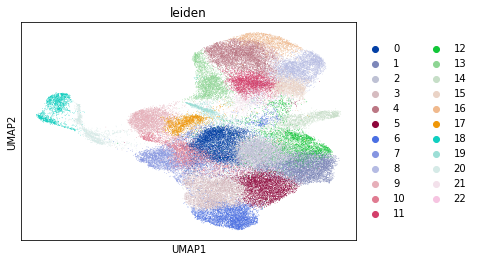

In [14]:
sc.pl.umap(adata, color=['leiden'], save='_D16_leiden.png')

# Figure panel S2K

UMAPs of D16 cells colored by assigned cell type

In [15]:
# Assign cell type names to each of the leiden clusters
labeldict={'0':'Caudal vMB progenitors',
           '1':'vMB progenitors',
           '2':'vMB progenitors',
           '3':'vFB progenitors',
           '4':'vMB progenitors (cycling, G1/S phase)',
           '5':'Rostral vMB/caudal vFB progenitors',
           '6':'vFB progenitors',
           '7':'vMB/BP progenitors',
           '8':'vFB progenitors (cycling, M/G2 phase)',
           '9':'Rostral vHB progenitors',
           '10':'Progenitors (subtype unknown)',
           '11':'vMB progenitors (cycling, M/G2 phase)',
           '12':'vMB progenitors',
           '13':'vHB progenitors (cycling)',
           '14':'vFB/vMB progenitors (cycling)',
           '15':'vMB progenitors (cycling, M/G2 phase)',
           '16':'vFB progenitors (cycling, G1/S phase)',
           '17':'vMB/vHB progenitors',
           '18':'Glutamatergic neurons',
           '19':'Progenitors (high ECM/Actin-regulation)',
           '20':'Immature neurons and motor neurons',
           '21':'vFB/vMB progenitors (cycling)',
           '22':'vMB progenitors',

           }

adata.obs['cell_type']=[labeldict[x] for x in adata.obs['leiden']]

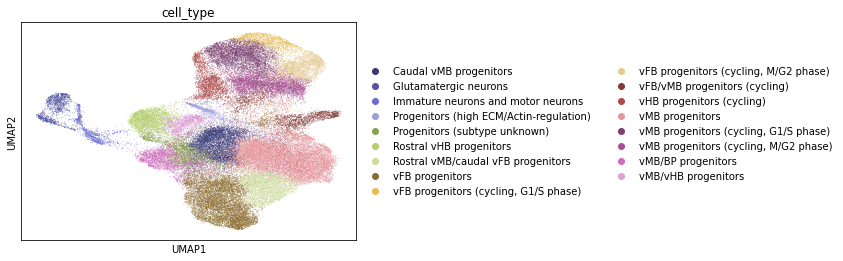

In [16]:
sc.pl.umap(adata, color=['cell_type'], palette='tab20b', save='_D16_celltype.png')

# Figure panel S2L

UMAPs of D16 cells colored by scaled and normalized expressions of SOX2, MKI67 and GAP43

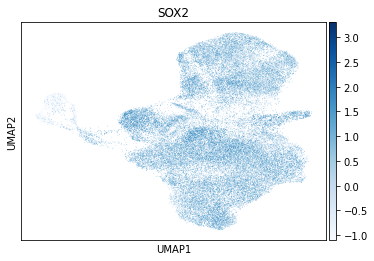

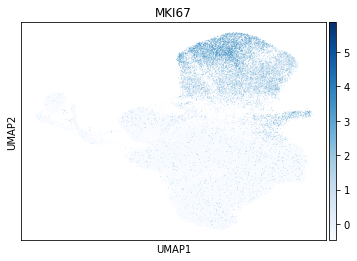

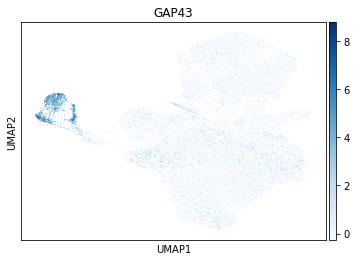

In [17]:
# color UMAP based on genes of interest
sc.pl.umap(adata, color=['SOX2'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D16_SOX2.png')
sc.pl.umap(adata, color=['MKI67'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D16_MKI67.png',)
sc.pl.umap(adata, color=['GAP43'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D16_GAP43.png',)

# Figure panel S2M

UMAPs of D16 cells from human colored by scaled and normalized expression of genes with distinct regional distributions along the rostro-caudal axis

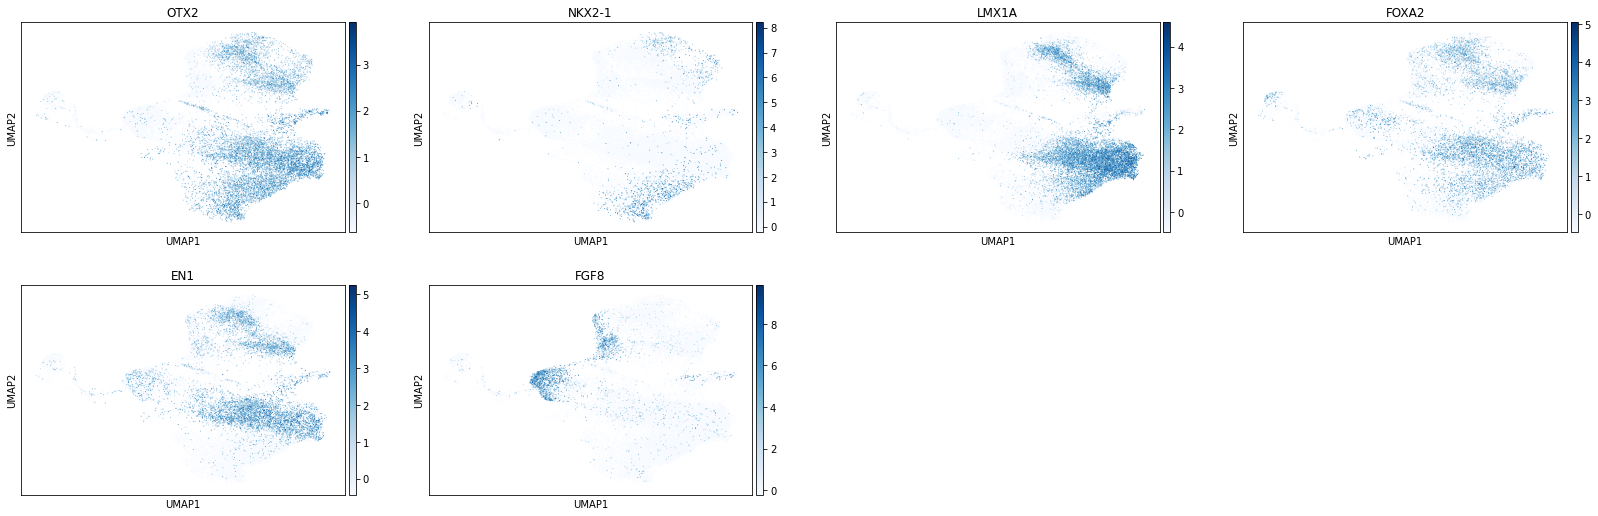

In [18]:
adata_humans = adata.obs['species'].str.contains('human')
sc.pl.umap(adata[adata_humans,:],color=['OTX2', 'NKX2-1', 'LMX1A', 'FOXA2', 'EN1', 'FGF8'], use_raw=False,    
    palette="Set2", color_map=matplotlib.cm.Blues, save='_human-rostro-caudal-genes.png')

# Figure panel S2N

UMAPs of D16 cells from chimpanzee colored by scaled and normalized expression of genes with distinct regional distributions along the rostro-caudal axis

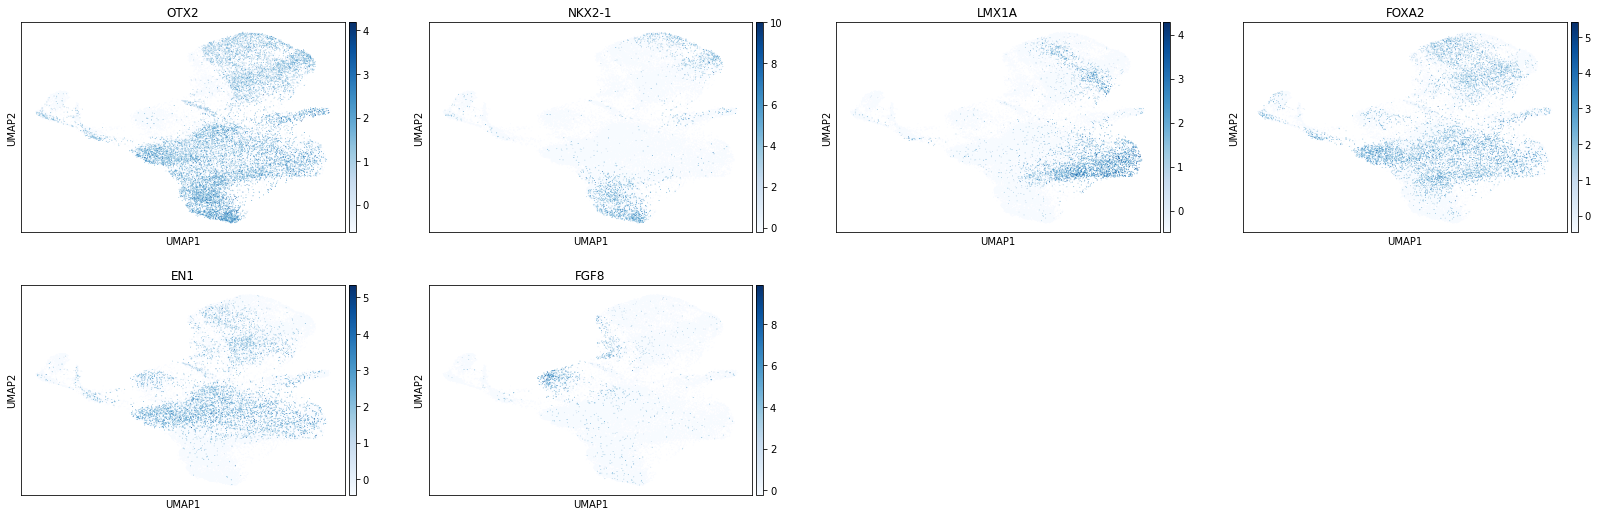

In [19]:
adata_chimp = adata.obs['species'].str.contains('chimp')
sc.pl.umap(adata[adata_chimp,:],color=['OTX2', 'NKX2-1', 'LMX1A', 'FOXA2', 'EN1', 'FGF8'], use_raw=False,    
    palette="Set2", color_map=matplotlib.cm.Blues, save='_chimp-rostro-caudal-genes.png')